# Scalable MatMul-free Language Modeling

Zhu, Rui-Jie, Yu Zhang, Ethan Sifferman, et al. "Scalable MatMul-Free Language Modeling." arXiv:2406.02528. Preprint, arXiv, June 18, 2024. https://doi.org/10.48550/arXiv.2406.02528

In [ ]:
# \!pip install torch datasets matplotlib

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Eszköz: {device}")

Eszköz: cuda


In [ ]:
torch.manual_seed(42)

In [ ]:
@dataclass
class ModelConfig:
    vocab_size: int   = 256
    d_model:    int   = 128
    n_layers:   int   = 4
    n_heads:    int   = 4
    seq_len:    int   = 256
    dropout:    float = 0.1

config = ModelConfig()

## BitLinear – Mátrixszorzás nélküli lineáris réteg

Egy hagyományos `nn.Linear` réteg a következő műveletet végzi:

$$\mathbf{y} = \mathbf{x} \mathbf{W}^T$$

ahol $\mathbf{x} \in \mathbb{R}^{d_{in}}$ a bemenet, $\mathbf{W} \in \mathbb{R}^{d_{out} \times d_{in}}$ a súlymátrix. Ez egy **lebegőpontos mátrixszorzás**, amelynek bonyolultsága $O(d_{in} \cdot d_{out})$. Egy nagy modellben ezek teszik ki a számítás ~95%-át.

A BitLinear ezt váltja ki úgy, hogy a súlyokat **ternáris értékekre** ($\{-1, 0, +1\}$) kvantálja, az aktivációkat pedig **8-bites egészekre** – a szorzások így összeadásokká alakíthatók.

### RMSNorm – normalizáció

A kvantálás előtt az értékeket normalizálni kell – különben a kvantálás pontatlan lenne.

Az **RMSNorm** (Root Mean Square Normalization) képlete:

$$\text{RMSNorm}(\mathbf{x}) = \frac{\mathbf{x}}{\text{RMS}(\mathbf{x})} \cdot \boldsymbol{\gamma}$$

ahol:

$$\text{RMS}(\mathbf{x}) = \sqrt{\frac{1}{d} \sum_{i=1}^{d} x_i^2 + \varepsilon}$$

A $\boldsymbol{\gamma} \in \mathbb{R}^d$ **tanulható skálázási vektor** (kezdetben csupa 1), az $\varepsilon$ kis szám a numerikus stabilitáshoz, hogy ne forduljon elő 0-val való osztás.

**Lépések:**

1. Veszi a bemeneti vektort ($\mathbf{x}$) — pl. egy token 128 dimenziós reprezentációja
2. Minden elemet négyzetre emel — hogy az előjelektől függetlenül mérje a "nagyságot"
3. Átlagolja a négyzetes értékeket
4. Négyzetgyököt von — ezzel visszakapja az eredeti skálát → ez az RMS
5. Elosztja az eredeti vektort az RMS-sel → most már minden vektor hasonló "méretű"
6. Megszorozza a tanulható $\boldsymbol{\gamma}$ vektorral → a modell visszaállíthatja az optimális skálát

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms_inv = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).rsqrt()
        return x * rms_inv * self.weight

Ellenőrzés

In [ ]:
x_test = torch.randn(2, 10, config.d_model)
norm = RMSNorm(config.d_model)
x_normed = norm(x_test)

print(f"Bemenet alakja:  {x_test.shape}")
print(f"Kimenet alakja:  {x_normed.shape}")
print(f"Bemenet  átlag={x_test.mean():.3f}  std={x_test.std():.3f}")
print(f"Kimenet  átlag={x_normed.mean():.3f}  std={x_normed.std():.3f}")
print("A kimenet értékei normalizálódtak, std közel 1-hez.")

Bemenet alakja:  torch.Size([2, 10, 128])
Kimenet alakja:  torch.Size([2, 10, 128])
Bemenet  átlag=0.008  std=0.989
Kimenet  átlag=0.008  std=1.000
A kimenet értékei normalizálódtak, std közel 1-hez.


### Súlykvantálás – ternáris értékekre ($\{-1, 0, +1\}$)

A súlyok a neurális háló tanulható paraméterei, ezek határozzák meg, hogy egy adott bemeneti érték mennyire fontos, azaz mekkora hatással legyen a kimenetre.

Hagyományosan ezek tetszőleges lebegőpontos számok, azonban a ternáris kvantálás után csak **({-1, 0, +1\})** értéket vehetnek fel:

−1 esetén az érték negálódik (ellentétes hatás),

0 esetén teljesen figyelmen kívül marad (nincs hatás),

+1 esetén pedig változatlanul átmegy (pozitív hatás).

**Lépések:**

**1.** Skálafaktor: az abszolút értékek átlaga:
$$\alpha = \frac{1}{nm} \sum_{ij} |W_{ij}|$$

**2.** Skálázás és kerekítés:
$$\tilde{W}_{ij} = \text{round}\left(\frac{W_{ij}}{\alpha}\right)$$

**3.** Szorítás $[-1, 1]$-re:
$$W^{\text{quant}}_{ij} = \text{clamp}(\tilde{W}_{ij},\ -1,\ 1)$$

**4.** Visszaskálázás (hogy a numerikus skála megmaradjon):

$$W^{\text{final}}_{ij} = W^{\text{quant}}_{ij} \cdot \alpha$$

A visszaskálázás azért szükséges, mert a PyTorch `F.linear` művelete float32 értékeket vár — a ternáris **({-1, 0, +1\})** értékeket visszaszorozzuk α-val hogy a kimenet nagyságrendje helyes maradjon. Valódi hardveres implementációban (pl. Loihi 2) ez a lépés elhagyható.

In [ ]:
def weight_quant(w: torch.Tensor) -> torch.Tensor:
    alpha = w.abs().mean().clamp_(min=1e-5)
    w_quant = (w / alpha).round().clamp_(-1, 1)
    return w_quant * alpha

Ellenőrzés

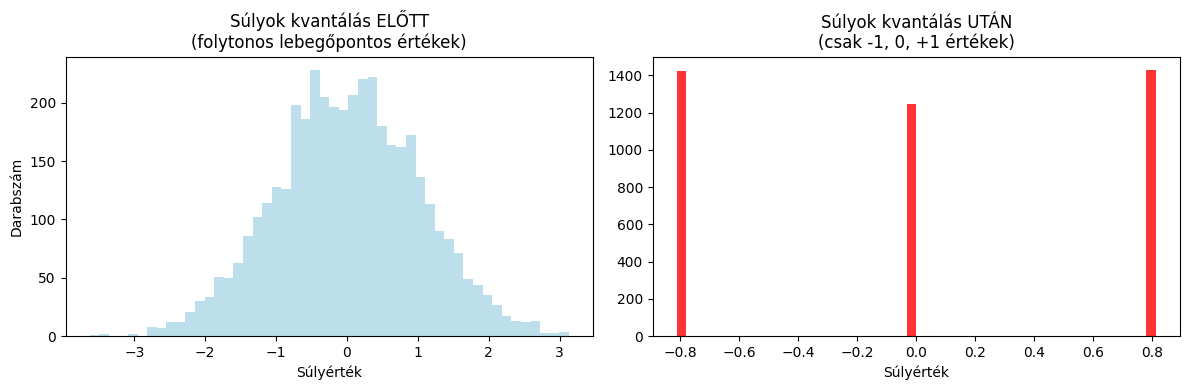


Egyedi értékek kvantálás és visszaskálázás után: [-0.812, 0.0, 0.812]
Csak 3 különböző érték van (ternáris kvantálás)!


In [ ]:
w_ex = torch.randn(64, 64)
w_q  = weight_quant(w_ex)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(w_ex.flatten().numpy(), bins=50, color='lightblue', alpha=0.8)
axes[0].set_title('Súlyok kvantálás ELŐTT\n(folytonos lebegőpontos értékek)')
axes[0].set_xlabel('Súlyérték')
axes[0].set_ylabel('Darabszám')

axes[1].hist(w_q.flatten().detach().numpy(), bins=50, color='red', alpha=0.8)
axes[1].set_title('Súlyok kvantálás UTÁN\n(csak -1, 0, +1 értékek)')
axes[1].set_xlabel('Súlyérték')

plt.tight_layout()
plt.show()

unique_vals = sorted(w_q.unique().tolist())
print()
print(f"Egyedi értékek kvantálás és visszaskálázás után: {[round(v,3) for v in unique_vals]}")
print(f"Csak 3 különböző érték van (ternáris kvantálás)!")

### Aktivációkvantálás – 8 bitre

Az aktivációkat, azaz a réteg bemeneti vektorait a rendszer token-szinten kvantálja 8-bites egészekre, a $[−128,127]$ tartományba.

A token-szintű kvantálás azt jelenti, hogy minden pozícióhoz külön skálafaktor kerül kiszámításra, így minden token kihasználja a saját dinamikatartományát.

A dinamikatartomány azt jelenti, hogy egy token értékei milyen nagy számok között mozognak — van amelyik 0.1 és 0.3 között, van amelyik 7 és 9 között. Ha minden tokenre ugyanazt a skálát használnánk, a kis értékű tokenek szinte mind ugyanarra a néhány egészre kvantálódnának, elveszítve a köztük lévő különbségeket. Ezért minden token a saját értékkészletéhez igazított skálát kap.

A képletekben $t$ a token pozícióját, $j$ pedig az adott token feature-vektorának
dimenzióindexét jelöli.

**Lépések:**

**1.** Token-szintű skálafaktor ($t$-edik tokenre):
$$s_t = \frac{127}{\max_j |x_{t,j}|}$$

**2.** Skálázás, kerekítés, szorítás:
$$x^{\text{int8}}_{t,j} = \text{clamp}\left(\text{round}(x_{t,j} \cdot s_t),\ -128,\ 127\right)$$

**3.** Visszaskálázás:
$$x^{\text{final}}_{t,j} = \frac{x^{\text{int8}}_{t,j}}{s_t}$$

A visszaskálázás azért szükséges, mert a PyTorch következő rétegei float32 értékeket várnak — ha a **[-128, 127]** egész értékeket visszaosztatlanul adnánk tovább, a modell teljesen félreértelmezné őket és a tanítás összeomolna. Ezért visszaosztunk s_t​-vel hogy az értékek visszakerüljenek az eredeti nagyságrendbe. Valódi int8 hardveres támogatással ez a lépés elhagyható lenne.

In [ ]:
def activation_quant(x: torch.Tensor) -> torch.Tensor:
    scale = 127.0 / x.abs().max(dim=-1, keepdim=True).values.clamp_(min=1e-5)
    return (x * scale).round().clamp_(-128, 127) / scale

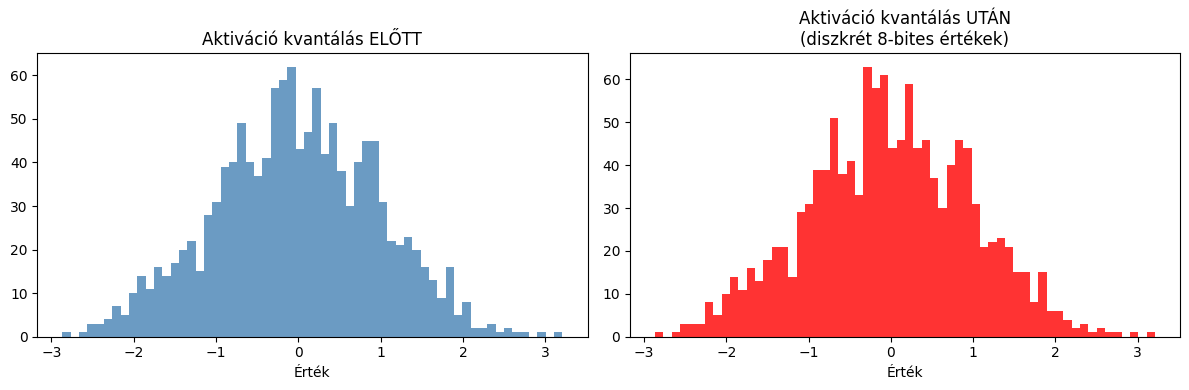

In [ ]:
x_act = torch.randn(4, 10, 32)
x_qact = activation_quant(x_act)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_act.flatten().numpy(), bins=60, color='steelblue', alpha=0.8)
axes[0].set_title('Aktiváció kvantálás ELŐTT')
axes[0].set_xlabel('Érték')
axes[1].hist(x_qact.flatten().detach().numpy(), bins=60, color='red', alpha=0.8)
axes[1].set_title('Aktiváció kvantálás UTÁN\n(diszkrét 8-bites értékek)')
axes[1].set_xlabel('Érték')
plt.tight_layout()
plt.show()

### Straight-Through Estimator (STE)

A probléma: A matematika szabályai szerint a valódi gradienst így kéne kiszámolni:$$\frac{\partial \mathcal{L}}{\partial x} = \frac{\partial \mathcal{L}}{\partial x^{\text{quant}}} \cdot \frac{\partial x^{\text{quant}}}{\partial x}$$


Mivel azonban a kerekítés egy lépcsős függvény, a deriváltja ($\frac{\partial x^{\text{quant}}}{\partial x}$) majdnem mindenhol nulla. Ha nullával történik a szorzás, a gradiens eltűnik, és a tanulás leáll.

A megoldás:  Előrefelé a kvantálás megtörténik, hátrafelé viszont úgy viselkedik a rendszer, mintha a kvantálás meg sem történt volna.

$$x^{\text{quant}} = x + \underbrace{(\text{round}(x) - x)}_{\text{.detach()}}$$

Forward pass: A .detach() az értékeket nem bántja, így az eredmény egyszerűen $\text{round}(x)$ lesz. A modell a kvantált értékkel számol.

Backward pass: A .detach() azt mondja PyTorchnak, hogy a kerekítési műveletet hagyja figyelmen kívül a gradiens számításakor. Így a gradiens úgy folyik vissza a súlyokhoz, mintha a kerekítés meg sem történt volna — a modell tanulni tud, miközben a forward passban a kvantált értékekkel számol

Matematikailag ez egy közelítés:

$$\frac{\partial \mathcal{L}}{\partial x} \approx \frac{\partial \mathcal{L}}{\partial x^{\text{quant}}}$$

Ez a képlet azt mutatja, hogy a láncszabály kiszámításakor szándékosan ignoráljuk a kerekítés deriváltját. Így a gradiens akadálytalanul eljut a háttérben lévő lebegőpontos súlyokhoz, amelyek lassan addig frissülnek, amíg át nem billennek a következő kvantált állapotba pl. 0-ból 1-be.

ahol:
- $\mathcal{L}$ – a loss (veszteség), amit minimalizálni akarunk
- $x$ – az eredeti, kvantálás előtti érték (float32)
- $x^{\text{quant}}$ – a kvantált érték (kerekítés után)
- $\frac{\partial \mathcal{L}}{\partial x}$ – a loss gradiense $x$-re nézve (ezt keressük)
- $\frac{\partial x^{\text{quant}}}{\partial x}$ – a kerekítés deriváltja (ez lenne nulla STE nélkül)

In [ ]:
x_demo = torch.tensor([0.7, -0.3, 1.2, -0.8], requires_grad=True)

x_demo.grad = None
x_rounded = x_demo.round()
x_rounded.sum().backward()
print(f"Gradiens STE NÉLKÜL: {x_demo.grad}")
print("Csupa nulla. A round() gradiensei nullák, a modell nem tanulna.")
print()

x_demo.grad = None
x_ste = x_demo + (x_demo.round() - x_demo).detach()
x_ste.sum().backward()
print(f"Gradiens STE-VEL: {x_demo.grad}")
print("Csupa 1.0. A gradiens átment, a modell tanulni tud.")
print()
print(f"Eredeti forward értékek:         {x_demo.data}")
print(f"Forward értékek STE-vel: {x_ste.data}")
print("Forward passban kerekített értékek, backward passban valódi gradiens!")

Gradiens STE NÉLKÜL: tensor([0., 0., 0., 0.])
Csupa nulla. A round() gradiensei nullák, a modell nem tanulna.

Gradiens STE-VEL: tensor([1., 1., 1., 1.])
Csupa 1.0. A gradiens átment, a modell tanulni tud.

Eredeti forward értékek:         tensor([ 0.7000, -0.3000,  1.2000, -0.8000])
Forward értékek STE-vel: tensor([ 1.,  0.,  1., -1.])
Forward passban kerekített értékek, backward passban valódi gradiens!


### BitLinear – az összes elem összerakva



A teljes forward pass:

$$y = F_{\text{linear}}\left(\hat{x}^{\text{quant}},\ \hat{W}^{\text{quant}}\right)$$

ahol:
- $\hat{x} = \text{RMSNorm}(x)$ – normalizált bemenet
- $\hat{x}^{\text{quant}} = \hat{x} + (\text{activation_quant}(\hat{x}) - \hat{x})\text{.detach()}$ – STE-kvantált aktiváció
- $\hat{W}^{\text{quant}} = W + (\text{weight_quant}(W) - W)\text{.detach()}$ – STE-kvantált súlyok

In [ ]:
class BitLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, bias: bool = False):
        super().__init__(in_features, out_features, bias=bias)
        self.norm = RMSNorm(in_features, eps=1e-8)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_norm = self.norm(x)
        x_quant = x_norm + (activation_quant(x_norm) - x_norm).detach()
        w = self.weight
        w_quant = w + (weight_quant(w) - w).detach()
        return F.linear(x_quant, w_quant, self.bias)

Ellenőrzés: BitLinear vs nn.Linear

In [ ]:
d_in = d_out = 128

x_test = torch.randn(1, 10, d_in)

linear    = nn.Linear(d_in, d_out, bias=False)

bitlinear = BitLinear(d_in, d_out, bias=False)
bitlinear.weight.data = linear.weight.data.clone()

y_lin = linear(x_test)
y_bit = bitlinear(x_test)

print(f"nn.Linear  kimenet alakja: {y_lin.shape}")
print(f"BitLinear  kimenet alakja: {y_bit.shape}")
print()

total_weights = d_in * d_out
print(f"Összes súly száma: {total_weights:,}")
print(f"nn.Linear  memória: {total_weights * 4:,} bájt  (float32, 32 bit/érték)")
print(f"BitLinear  memória: {total_weights * 1.58 / 8:.0f} bájt  (ternáris, 1.58 bit/érték)")
print(f"Megtakarítás: ~{4 / (1.58/8):.0f}x")

nn.Linear  kimenet alakja: torch.Size([1, 10, 128])
BitLinear  kimenet alakja: torch.Size([1, 10, 128])

Összes súly száma: 16,384
nn.Linear  memória: 65,536 bájt  (float32, 4 bájt/érték)
BitLinear  memória: 3236 bájt  (ternáris, 1.58 bit/érték)
Megtakarítás: ~20x


Fontos megjegyzés, hogy ez a memóriaszámítás elméleti. A PyTorch implementációban mindkét réteg valójában float32-t tárol, tehát a memóriahasználat jelenleg azonos. A valódi megtakarítás csak dedikált hardveren (pl. Intel Loihi 2, FPGA) érhető el, ahol a ternáris súlyokat tényleg 1.58 biten tárolják float32 helyett.

## MatMul-free Linear Gated Recurrent Unit (MLGRU) – Lineáris rekurrencia az önfigyelem helyett

 A hagyományos önfigyelem (self-attention) legnagyobb szűk keresztmetszete a $\mathbf{Q}\mathbf{K}^T$ mátrixszorzat, amelynek kiszámítása $O(n^2 d)$ bonyolultságú (ahol $n$ a szekvencia hossza, a $d$ a reprezentáció dimenziója).

 Bár a BitLinear rétegekkel a kezdeti vetítések kvantálhatók, a dinamikus $\mathbf{Q}\mathbf{K}^T$ mátrixszorzat továbbra is megmaradna, ami lehetetlenné tenné a MatMul-mentes működést.

Ennek kiküszöbölésére a modell az önfigyelmet egy kapuzott lineáris rekurrens egységgel (MLGRU) váltja ki. Az MLGRU nem hasonlítja össze a tokeneket egymással mint a self-attention, helyette egy rejtett állapotot ($\mathbf{h}_t$) frissít időlépésenként, amely fokozatosan összesűríti az összes korábbi token információját. Ez a mechanizmus kizárólag elem-szintű szorzásokat ($\odot$) és összeadásokat használ, így a mátrixszorzás maradéktalanul eltűnik a folyamatból.

### A rekurrencia képlete

Legyen $\mathbf{x}_t \in \mathbb{R}^{d}$ a $t$-edik token **bemeneti vektora** — ez a token embedding és pozicionális encoding összege, $d$ dimenziós reprezentáció. Az MLGRU időlépésenként frissíti a **rejtett állapotot** ($\mathbf{h}_t \in \mathbb{R}^{d}$) az alábbi lineáris rekurrenciával:

$$\mathbf{h}_t = \mathbf{f}_t \odot \mathbf{h}_{t-1} + \mathbf{i}_t$$

ahol:
- $\mathbf{f}_t \in (0, 1)^d$ – a **felejtési kapu** *(forget gate)*.
- $\mathbf{i}_t$ – a **bemeneti kapu** *(input gate)*.
- $\odot$ – **elem-szintű szorzás** (Hadamard-szorzat).

A kapuk értékeit BitLinear rétegekkel számítja ki, ahol a bemeneti kapu a felejtési kapu komplementerére épül:

$$\mathbf{f}_t = \sigma\left(\text{BitLinear}_f(\mathbf{x}_t)\right)$$
$$\mathbf{i}_t = \tau\left(\text{BitLinear}_i(\mathbf{x}_t)\right) \odot (1 - \mathbf{f}_t)$$

ahol:
- $\sigma$ a Sigmoid ($\sigma(x) = \frac{1}{1+e^{-x}}$, értéke mindig $(0,1)$ között van)
- $\tau$ pedig a SiLU ($\tau(x) = x \cdot \sigma(x)$, negatív értékeket is átengedi) aktivációs függvényt jelöli.

Ez a struktúra biztosítja, hogy a modell hatékonyan adagolja a múltbeli információk megtartását és az új adatok befogadását mátrixszorzás nélkül.

### MLGRU blokk implementációja

A szekvencia **idősorban kerül feldolgozásra**: minden tokenre kiszámításra kerülnek a kapuk, majd frissül a rejtett állapot.

A blokk felépítése:
1. **BitLinear vetítések** → $\mathbf{f}_t$ (felejtési kapu), $\mathbf{i}_t$ (bemeneti érték) és $\mathbf{g}_t$ (kimeneti kapu) előállítása.
2. **Rekurrencia** → $\mathbf{h}_t = \mathbf{f}_t \odot \mathbf{h}_{t-1} + \mathbf{i}_t$
3. **Kimeneti kapuzás** → a rejtett állapot ($\mathbf{h}_t$) szűrése a kimeneti kapuval ($\mathbf{g}_t$)

A kimeneti kapu ($\mathbf{g}_t$) szintén $\mathbf{x}_t$-ből számolódik egy BitLinear rétegen keresztül:

$$\mathbf{g}_t = \text{BitLinear}_g(\mathbf{x}_t)$$
$$o'_t = \mathbf{g}_t \odot \sigma(\mathbf{h}_t)$$

A rejtett állapotot ($\mathbf{h}_t$) sigmoid-dal normalizáljuk $(0,1)$-re, majd elem-szintű szorzással kombináljuk $\mathbf{g}_t$-vel — ez szabályozza hogy a rejtett állapot mely részei legyenek erősek a kimenetben és melyek halkuljanak el, mint egy hangerőszabályozó minden dimenzióra külön.

In [ ]:
class MLGRULayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()

        self.d_model = d_model
        self.n_heads = n_heads

        self.head_dim = d_model // n_heads

        self.f_proj = BitLinear(d_model, d_model, bias=False)
        self.i_proj = BitLinear(d_model, d_model, bias=False)
        self.g_proj = BitLinear(d_model, d_model, bias=False)

        self.out_norm = RMSNorm(d_model)
        self.o_proj  = BitLinear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape  # batch, seq_len, d_model

        f = self.f_proj(x).sigmoid()
        i = F.silu(self.i_proj(x)) * (1 - f)
        h = torch.zeros(B, self.n_heads, self.head_dim, device=x.device, dtype=x.dtype)

        i_heads = i.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        f_heads = f.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        outputs = []
        for t in range(T):
            h = f_heads[:, :, t, :] * h + i_heads[:, :, t, :]
            outputs.append(h)

        o = torch.stack(outputs, dim=2)
        o = o.transpose(1, 2).contiguous().view(B, T, D)

        g = self.g_proj(x)
        o = self.out_norm(o) * g.sigmoid()

        return self.o_proj(o)

Ellenőrzés.

In [ ]:
mlgru = MLGRULayer(d_model=config.d_model, n_heads=config.n_heads).to(device)
x_test = torch.randn(2, config.seq_len, config.d_model).to(device)

y_mlgru = mlgru(x_test)

print(f"Bemenet alakja:  {x_test.shape}")
print(f"Kimenet alakja:  {y_mlgru.shape}")
print(f"Az MLGRU réteg megőrzi az alakot: (batch, seq_len, d_model)")
print()

mlgru_params = sum(p.numel() for p in mlgru.parameters())

mha = nn.MultiheadAttention(config.d_model, config.n_heads, batch_first=True)
mha_params  = sum(p.numel() for p in mha.parameters())

print(f"MLGRU paraméterei:  {mlgru_params:,}")
print(f"MHA  paraméterei:  {mha_params:,}")
print(f"Hasonló paraméterszám, de MLGRU-ban nincs QK^T mátrixszorzás!")

Bemenet alakja:  torch.Size([2, 256, 128])
Kimenet alakja:  torch.Size([2, 256, 128])
Az MLGRU réteg megőrzi az alakot: (batch, seq_len, d_model)

MLGRU paraméterei:  66,176
MHA  paraméterei:  66,048
Hasonló paraméterszám, de MLGRU-ban nincs QK^T mátrixszorzás!


### SwiGLU – az aktivációs függvény



A SwiGLU (Swish-Gated Linear Unit) egy kapuzott aktivációs függvény:

$$\text{SwiGLU}(\mathbf{a}, \mathbf{b}) = \mathbf{a} \odot \text{SiLU}(\mathbf{b})$$

ahol a SiLU (Sigmoid Linear Unit):

$$\text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

Ez a függvény simán szabályozza, hogy melyik információ „áramlik át" – a $\mathbf{b}$ értéke kapuként működik, $\mathbf{a}$ az átbocsátott jel.

In [ ]:
def silu(x: torch.Tensor) -> torch.Tensor:
    return x * torch.sigmoid(x)

def swiglu(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return a * silu(b)

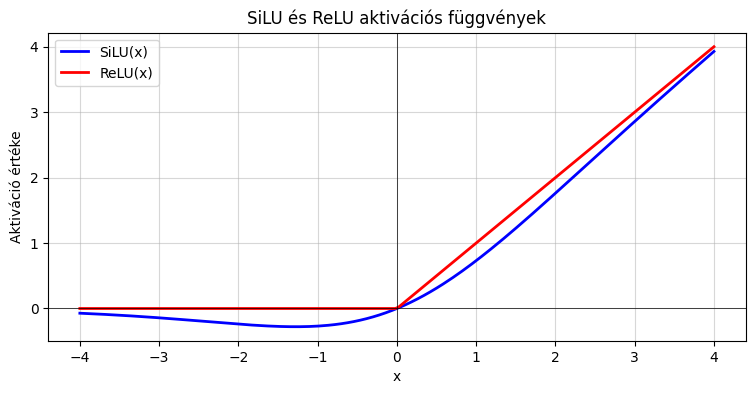


A SiLU simán negatív értékeket is átenged, ami jobb gradienst biztosít


In [ ]:
x_vis = torch.linspace(-4, 4, 200)

plt.figure(figsize=(9, 4))
plt.plot(x_vis.numpy(), silu(x_vis).numpy(), label='SiLU(x)', color='blue', linewidth=2)
plt.plot(x_vis.numpy(), torch.relu(x_vis).numpy(), label='ReLU(x)', color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('SiLU és ReLU aktivációs függvények')
plt.xlabel('x')
plt.ylabel('Aktiváció értéke')
plt.legend()
plt.grid(alpha=0.5)
plt.show()
print()
print("A SiLU simán negatív értékeket is átenged, ami jobb gradienst biztosít")

### BitMLP - Feed-Forward hálózat BitLinear-ral

A transzformer alapú modellek minden blokkja tartalmaz egy Feed-Forward hálózatot (MLP) a sorozatok feldolgozása után. Míg az önfigyelem (vagy az MLGRU) az *időben* keveri az információt a szavak között, addig az MLP a szavak *saját, belső tulajdonságait* (dimenzióit) keveri újra, pozíciónként függetlenül.

A hagyományos transzformerekben ez két egyszerű lineáris vetítésből és egy ReLU aktivációból áll:

$$\text{MLP}(\mathbf{x}) = \mathbf{W}_{\text{down}} \cdot \text{ReLU}(\mathbf{W}_{\text{up}} \mathbf{x})$$

ahol $\mathbf{W}_{\text{up}}$ felskálázza a bemenetet nagyobb dimenzióba, $\mathbf{W}_{\text{down}}$ pedig visszahozza az eredeti dimenzióba.

A MatMul-free architektúrában a drága lebegőpontos rétegeket **BitLinear** modulokra cseréljük, a standard ReLU helyett a **SwiGLU** (Swish Gated Linear Unit) mechanizmust használjuk.

A SwiGLU különlegessége, hogy az egyszerű aktiváció helyett *két párhuzamos* lineáris réteget használ: az egyik az adatokat kiterjeszti (`up`), a másik pedig egy „kapuként" (`gate`) működve finoman szabályozza, hogy ebből az információból mi áramolhasson tovább:

$$\text{BitMLP}(\mathbf{x}) = \text{BitLinear}_{\text{down}}\left(\text{SwiGLU}\left(\text{BitLinear}_{\text{gate}}(\mathbf{x}),\ \text{BitLinear}_{\text{up}}(\mathbf{x})\right)\right)$$

ahol $\text{BitLinear}_{\text{gate}}(\mathbf{x})$ az átbocsátott jel ($\mathbf{a}$), $\text{BitLinear}_{\text{up}}(\mathbf{x})$ pedig a kapu ($\mathbf{b}$).

A belső kiterjesztett dimenzió az alapdimenzió többszöröse (általában $4 \times d_{\text{model}}$) — több összefüggést tud megtanulni, mint egy gondolkodási folyamat ahol kiterjesztjük a lehetőségeket, majd visszasűrítjük a lényeget.

In [ ]:
class BitMLP(nn.Module):
    def __init__(self, d_model: int, expansion_factor: int = 4):
        super().__init__()
        d_inner = int(d_model * expansion_factor * 2 / 3)
        d_inner = 64 * ((d_inner + 63) // 64)

        self.gate_proj = BitLinear(d_model, d_inner, bias=False)
        self.up_proj   = BitLinear(d_model, d_inner, bias=False)

        self.down_proj = BitLinear(d_inner, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.down_proj(swiglu(self.gate_proj(x), self.up_proj(x)))

**Megjegyzés a belső dimenzióról:** A SwiGLU két párhuzamos réteget használ (`gate_proj` és `up_proj`), ami kétszer annyi paramétert jelentene mint egy hagyományos MLP-ben. Ezért a belső dimenziót $\frac{2}{3}$-ára csökkentjük, hogy a teljes paraméterszám egyezzen egy hagyományos MLP-vel. Ez a korrekció minden SwiGLU-t használó modellnél szükséges.

## MatMulFree blokk

Egy teljes modellblokk az MLGRU réteget és a BitMLP-t kombinálja **reziduális kapcsolatokkal**.

A **reziduális kapcsolat** (skip connection) azt jelenti, hogy a réteg kimenetéhez hozzáadjuk az eredeti bemenetet:

$$\mathbf{x}' = \mathbf{x} + \text{MLGRU}(\text{RMSNorm}(\mathbf{x}))$$
$$\mathbf{x}'' = \mathbf{x}' + \text{BitMLP}(\text{RMSNorm}(\mathbf{x}'))$$

In [ ]:
class MatMulFreeBlock(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()

        self.norm1 = RMSNorm(config.d_model)
        self.norm2 = RMSNorm(config.d_model)

        self.mlgru = MLGRULayer(config.d_model, config.n_heads)
        self.mlp  = BitMLP(config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.dropout(self.mlgru(self.norm1(x)))
        x = x + self.dropout(self.mlp(self.norm2(x)))

        return x

Ellenőrzés

In [ ]:
block = MatMulFreeBlock(config).to(device)
x_test = torch.randn(2, config.seq_len, config.d_model).to(device)

y_block = block(x_test)

print(f"Bemenet alakja:  {x_test.shape}")
print(f"Kimenet alakja:  {y_block.shape}")
print(f"A blokk megőrzi az alakot: (batch, seq_len, d_model)")
print()

block_params = sum(p.numel() for p in block.parameters())
print(f"Egy blokk paraméterei: {block_params:,}")
print(f"4 blokk összesen:      {block_params * config.n_layers:,}")

Bemenet alakja:  torch.Size([2, 256, 128])
Kimenet alakja:  torch.Size([2, 256, 128])
A blokk megőrzi az alakot: (batch, seq_len, d_model)

Egy blokk paraméterei: 214,528
4 blokk összesen:      858,112


## MatMulFree nyelvi modell

A teljes modell:

1. **Token beágyazás** – egész indexekből (0-tól 255-ig, mivel `vocab_size=256`) $d$-dimenziós vektorokat csinál
2. **Pozicionális beágyazás** – megmondja a modellnek, hol van az adott token a szekvenciában
3. **N × MatMulFree blokk** – a tényleges feldolgozás
4. **Végső RMSNorm** – a kimenet normalizálása
5. **LM Head (BitLinear)** – visszavetít `vocab_size` méretre → ezek a **logitok** (nyers, nem normalizált valószínűségek)

A logitokból a **softmax** adja meg az egyes tokenek valószínűségét:

$$P(\text{token}_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

ahol:
- $z_i$ – az $i$-edik token logitja (a nyers, nem normalizált érték amit az LM Head ad vissza)
- $i$ – annak a tokennek az indexe amelynek a valószínűségét számítjuk (pl. $i=65$ az "A" betű)
- $j$ – összegzési index ami végigmegy az összes lehetséges tokenen (0-tól 255-ig), hogy az összes valószínűség összege 1 legyen

In [ ]:
class MatMulFreeLM(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_emb = nn.Embedding(config.seq_len, config.d_model)

        self.drop = nn.Dropout(config.dropout)

        self.blocks = nn.ModuleList([MatMulFreeBlock(config) for _ in range(config.n_layers)])
        self.norm_final = RMSNorm(config.d_model)
        self.lm_head = BitLinear(config.d_model, config.vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, BitLinear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        B, T = idx.shape
        assert T <= self.config.seq_len, f"Szekvencia ({T}) meghaladja a max hosszt ({self.config.seq_len})"

        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = self.drop(tok + pos)

        for block in self.blocks:
            x = block(x)

        x = self.norm_final(x)

        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, self.config.vocab_size), targets.view(-1))

        return logits, loss

Modell inicializálása és paraméterszám ellenőrzése

In [ ]:
model = MatMulFreeLM(config).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Összes paraméter:    {total_params:,}")
print(f"Tanítható paraméter: {trainable:,}")
print()

x_dummy = torch.randint(0, config.vocab_size, (2, config.seq_len)).to(device)
logits, _ = model(x_dummy)
print(f"Bemenet alakja:  {x_dummy.shape}  (batch=2, seq_len={config.seq_len})")
print(f"Logitok alakja:  {logits.shape}   (batch=2, seq_len={config.seq_len}, vocab={config.vocab_size})")
print()
print(f"Minden tokenhez {config.vocab_size} logit van, a modell ezek alapján jósolja a következő tokent.")

Összes paraméter:    956,672
Tanítható paraméter: 956,672

Bemenet alakja:  torch.Size([2, 256])  (batch=2, seq_len=256)
Logitok alakja:  torch.Size([2, 256, 256])   (batch=2, seq_len=256, vocab=256)

Minden tokenhez 256 logit van, a modell ezek alapján jósolja a következő tokent.


### Adathalmaz és tokenizálás

A legegyszerűbb tokenizálási módszer: **byte-szintű (karakterszintű)** megközelítés kerül alkalmazásra: minden UTF-8 bájt külön tokenként kezelődik.

Az adat **átfedő ablakokra** kerül vágásra: a modell `seq_len` hosszú szövegdarabokat lát, és minden pozícióban megjósolja a következő tokent.

Adathalmaz

In [ ]:
import os, urllib.request

# TinyShakespeare: ~1MB, Shakespeare osszes muve
if not os.path.exists("input.txt"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
        "input.txt"
    )
    print("Letöltve!")

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Szöveg hossza: {len(text):,} karakter")

Szöveg hossza: 1,115,394 karakter


Tokenizálás

In [ ]:
data = torch.tensor(list(text.encode('utf-8')), dtype=torch.long)

print(f"Token-sorozat hossza:  {len(data):,}")
print(f"Token értékkészlet:    0-{data.max().item()} (byte értékek)")
print(f"Első 13 token:         {data[:13].tolist()}")
print(f"Visszaalakítva szöveg: {bytes(data[:13].tolist()).decode('utf-8', errors='replace')}")
print()

split = int(len(data) * 0.9)
train_data = data[:split]
val_data   = data[split:]

print(f"Tanítási adatok:    {len(train_data):,} token")
print(f"Validációs adatok:  {len(val_data):,} token")

Token-sorozat hossza:  1,115,394
Token értékkészlet:    0-122 (byte értékek)
Első 13 token:         [70, 105, 114, 115, 116, 32, 67, 105, 116, 105, 122, 101, 110]
Visszaalakítva szöveg: First Citizen

Tanítási adatok:    1,003,854 token
Validációs adatok:  111,540 token


In [ ]:
def get_batch(data: torch.Tensor, batch_size: int, seq_len: int, device) -> tuple:
    ix = torch.randint(len(data) - seq_len, (batch_size,))

    x = torch.stack([data[i : i + seq_len] for i in ix])
    y = torch.stack([data[i + 1 : i + seq_len + 1] for i in ix])

    return x.to(device), y.to(device)

Ellenőrzés

In [ ]:
xb, yb = get_batch(train_data, batch_size=4, seq_len=config.seq_len, device=device)
print(f"Bemenet (x) alakja: {xb.shape}  (batch=4, seq_len={config.seq_len})")
print(f"Célérték (y) alakja: {yb.shape}")
print()
print(f"x első sorának első 10 tokenje:  {xb[0, :10].tolist()}")
print(f"y első sorának első 10 tokenje:  {yb[0, :10].tolist()}")
print()
print("y pontosan egy pozícióval el van tolva x-hez képest.")

Bemenet (x) alakja: torch.Size([4, 256])  (batch=4, seq_len=256)
Célérték (y) alakja: torch.Size([4, 256])

x első sorának első 10 tokenje:  [65, 78, 78, 69, 58, 10, 71, 111, 100, 32]
y első sorának első 10 tokenje:  [78, 78, 69, 58, 10, 71, 111, 100, 32, 103]

y pontosan egy pozícióval el van tolva x-hez képest.


## Tanítás

Az egész tanítási loop 4 lépésből áll.

1. **Véletlen mini-batch** kivágása az adatból
2. **Forward pass** – a modell megjósolja a következő tokeneket, kiszámítja a losst
3. **Backward pass** – a PyTorch kiszámítja az összes gradienst (`loss.backward()`)
4. **Súlyfrissítés** – az optimizer (AdamW) frissíti a súlyokat a gradiens alapján

Az **AdamW** optimizer az SGD (gradiens ereszkedés) egy fejlettebb változata, amely:
- Adaptívan állítja a tanulási rátát minden paraméterhez
- Weight decay-t alkalmaz (regularizáció a túltanulás ellen)


A kvantált (ternáris) modellek a kerekítési műveletek miatt a szokásosnál nagyobb tanulási rátát (1e-3 a 3e-4 helyett) igényelnek. Ha a frissítés mértéke túl apró, a kerekítés egyszerűen elnyeli azt, így a súlyok beragadnának és a modell nem tudna tanulni.


**Koszinuszos tanulási ráta ütemező (Cosine LR Scheduler):** A MatMul-free modellnél a tanulási dinamika eltér a hagyományos transzformerektől, ezért **koszinuszos ütemezőt** alkalmaznak. A tanítás elején nagy lépések történnek (gyors konvergencia), a végén egyre kisebb lépések (finom hangolás). A tanulási ráta a koszinusz-függvény szerint csökken LEARNING_RATE-ről eta_min-re:

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\frac{\pi t}{T}\right)$$

ahol $t$ az aktuális lépés, $T$ az összes lépés száma, $\eta_0$ a kezdeti tanulási ráta.

In [ ]:
BATCH_SIZE   = 16
LEARNING_RATE = 1e-3
MAX_ITERS    = 1000
EVAL_INTERVAL = 100
EVAL_ITERS   = 50

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

print(f"Modell paraméterei: {sum(p.numel() for p in model.parameters()):,}")
print(f"Tanítási lépések:   {MAX_ITERS:,}")
print(f"Batch méret:        {BATCH_SIZE}")

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_ITERS,
    eta_min=1e-5
)

Modell paraméterei: 956,672
Tanítási lépések:   1,000
Batch méret:        16


In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()

    for split, data in [('train', train_data), ('val', val_data)]:
        losses = []
        for _ in range(EVAL_ITERS):
            xb, yb = get_batch(data, BATCH_SIZE, config.seq_len, device)
            _, loss = model(xb, yb)
            losses.append(loss.item())
        out[split] = sum(losses) / len(losses)

    model.train()
    return out

In [ ]:
train_losses = []
val_losses   = []
log_steps    = []

print(f"Tanítás kezdete (eszköz: {device})")
print("-" * 50)

model.train()

for step in range(MAX_ITERS):

    if step % EVAL_INTERVAL == 0 or step == MAX_ITERS - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        log_steps.append(step)
        print(f"Lépés {step:4d} | tanítási loss: {losses['train']:.4f} | validációs loss: {losses['val']:.4f}")

    optimizer.zero_grad()
    xb, yb = get_batch(train_data, BATCH_SIZE, config.seq_len, device)
    logits, loss = model(xb, yb)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

print()
print("Tanítás kész!")

Tanítás kezdete (eszköz: cuda)
--------------------------------------------------
Lépés    0 | tanítási loss: 5.5501 | validációs loss: 5.5503
Lépés  100 | tanítási loss: 2.2626 | validációs loss: 2.2659
Lépés  200 | tanítási loss: 1.9557 | validációs loss: 2.0092
Lépés  300 | tanítási loss: 1.7974 | validációs loss: 1.8925
Lépés  400 | tanítási loss: 1.6950 | validációs loss: 1.8310
Lépés  500 | tanítási loss: 1.6193 | validációs loss: 1.7795
Lépés  600 | tanítási loss: 1.5735 | validációs loss: 1.7417
Lépés  700 | tanítási loss: 1.5319 | validációs loss: 1.7042
Lépés  800 | tanítási loss: 1.5087 | validációs loss: 1.6796
Lépés  900 | tanítási loss: 1.4950 | validációs loss: 1.6646
Lépés  999 | tanítási loss: 1.4884 | validációs loss: 1.6727

Tanítás kész!


Loss görbe

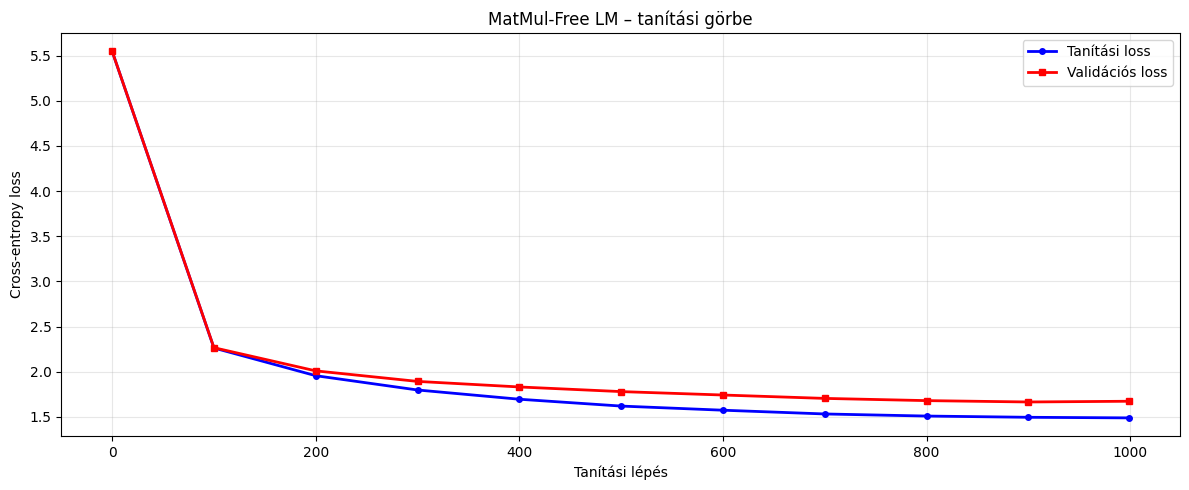

Kezdeti loss:   5.5501  (véletlenszerű jóslás esetén ~5.55)
Végső train:    1.4884
Végső val:      1.6727

Kezdeti perplexity:  257.3
Végső perplexity:    4.4


In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(log_steps, train_losses, label='Tanítási loss', color='blue', linewidth=2, marker='o', markersize=4)
plt.plot(log_steps, val_losses,   label='Validációs loss', color='red',   linewidth=2, marker='s', markersize=4)

plt.xlabel('Tanítási lépés')
plt.ylabel('Cross-entropy loss')
plt.title('MatMul-Free LM – tanítási görbe')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Kezdeti loss:   {train_losses[0]:.4f}  (véletlenszerű jóslás esetén ~{math.log(config.vocab_size):.2f})")
print(f"Végső train:    {train_losses[-1]:.4f}")
print(f"Végső val:      {val_losses[-1]:.4f}")
print()
print(f"Kezdeti perplexity:  {math.exp(train_losses[0]):.1f}")
print(f"Végső perplexity:    {math.exp(train_losses[-1]):.1f}")

## Szöveggenerálás

In [ ]:
@torch.no_grad()
def generate(model, prompt: str, max_new_tokens: int = 200, temperature: float = 1.0) -> str:
    model.eval()

    tokens = list(prompt.encode('utf-8'))
    idx = torch.tensor([tokens], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -config.seq_len:]

        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]

        logits = logits / temperature

        probs = F.softmax(logits, dim=-1)

        next_token = torch.multinomial(probs, num_samples=1)

        idx = torch.cat([idx, next_token], dim=1)

    generated_bytes = idx[0, len(tokens):].tolist()
    return bytes(generated_bytes).decode('utf-8', errors='replace')

prompt = "First Citizen"
generated = generate(model, prompt, max_new_tokens=150, temperature=0.8)
print(f"Prompt: {prompt}")
print(f"Generált szöveg:")
print()
print(prompt + generated)

Prompt: First Citizen
Generált szöveg:

First Citizen.

ROMEO:
She whose part our too
Since, these discit place of a frrayest honour!

Say?

Second ANLET:
Nay, I have them from the haste his confer provi
